 ## Figure 4 Code to Produce Figures



 This figure will focus on the presentation of Further Analysis of Extracted Assemblies.

In [1]:
# importing packages
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd
import pickle
import scipy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import squareform, pdist
import scipy.io
from scipy import stats
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from difflib import diff_bytes
import seaborn as sns
import h5py
import scipy
import os
import upsetplot
import ptitprince
import matplotlib.cm as cm
from statsmodels.stats.multitest import multipletests
import json
from tqdm import tqdm
plt.rcParams.update({'font.size': 18})
plt.rcParams["figure.figsize"] = (10,10)


# import v1dd_physiology.data_fetching as daf
# from statannotations.Annotator import Annotator

from matplotlib.colors import LinearSegmentedColormap

paired_blue0 = cm.get_cmap('Paired')(0)
paired_blue1 = cm.get_cmap('Paired')(1)

colors1 = ['grey', (.4, .6, .8, .5)]
colors2 = ['grey', (.2, .3, .5, .5), (.4, .6, .8, .5), 'white']
colors3 = [(.2, .3, .5, .5), 'white']
colors4 = ['grey', (.2, .3, .5, .5), (.4, .6, .8, .5),]
colors5 = [(.2, .3, .5, .5), (.4, .6, .8, .5), 'white']
colors6 = ['grey', 'steelblue', (.4, .6, .8, .5),]
colors7 = ['grey', 'steelblue']
colors8 = ['grey', 'cornflowerblue']
colors9 = ['grey', paired_blue1]
colors10 = ['dimgrey', paired_blue0]
greymap = LinearSegmentedColormap.from_list(
        "Custom", colors10, N=80) 

import ptitprince as pt

/var/folders/pf/3jc_0npn76z9n_c1pvb23kp00000gn/T/ipykernel_53142/1653120592.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  paired_blue0 = cm.get_cmap('Paired')(0)
/var/folders/pf/3jc_0npn76z9n_c1pvb23kp00000gn/T/ipykernel_53142/1653120592.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  paired_blue1 = cm.get_cmap('Paired')(1)


 ### Functional Connectivity Analysis


In [2]:
### Functions relevant for Oracle Score Analysis

def distance(x, y):
    return math.sqrt((x[0]-y[0])**2 + (x[1]-y[1])**2)

# def process(img):
#     img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     img_canny = cv2.Canny(img_gray, 0, 50)
#     img_dilate = cv2.dilate(img_canny, None, iterations=1)
#     img_erode = cv2.erode(img_dilate, None, iterations=1)
#     return img_erode

def get_assembly_time_trace(coactivity_trace, scores_in_order, name='scored_time_trace'):
    # Set up three subplots
    num_assemblies = coactivity_trace.shape[1]
    fig, ax = plt.subplots(num_assemblies, 1, figsize=(12, 12))

    # plot
    for i in range(num_assemblies):
        ax[i].plot(coactivity_trace[:, i], color='green')
        ax[i].set_ylabel(f"{scores_in_order[i]:.2}")
        ax[i].set_xlabel("Time Steps")
        ax[i].grid()

    fig.suptitle("Assembly Time Trace")
    #plt.savefig(f"oracle_dists2/assemblies_esteps_150000_affinity_04_{name}.png", dpi = 1200)


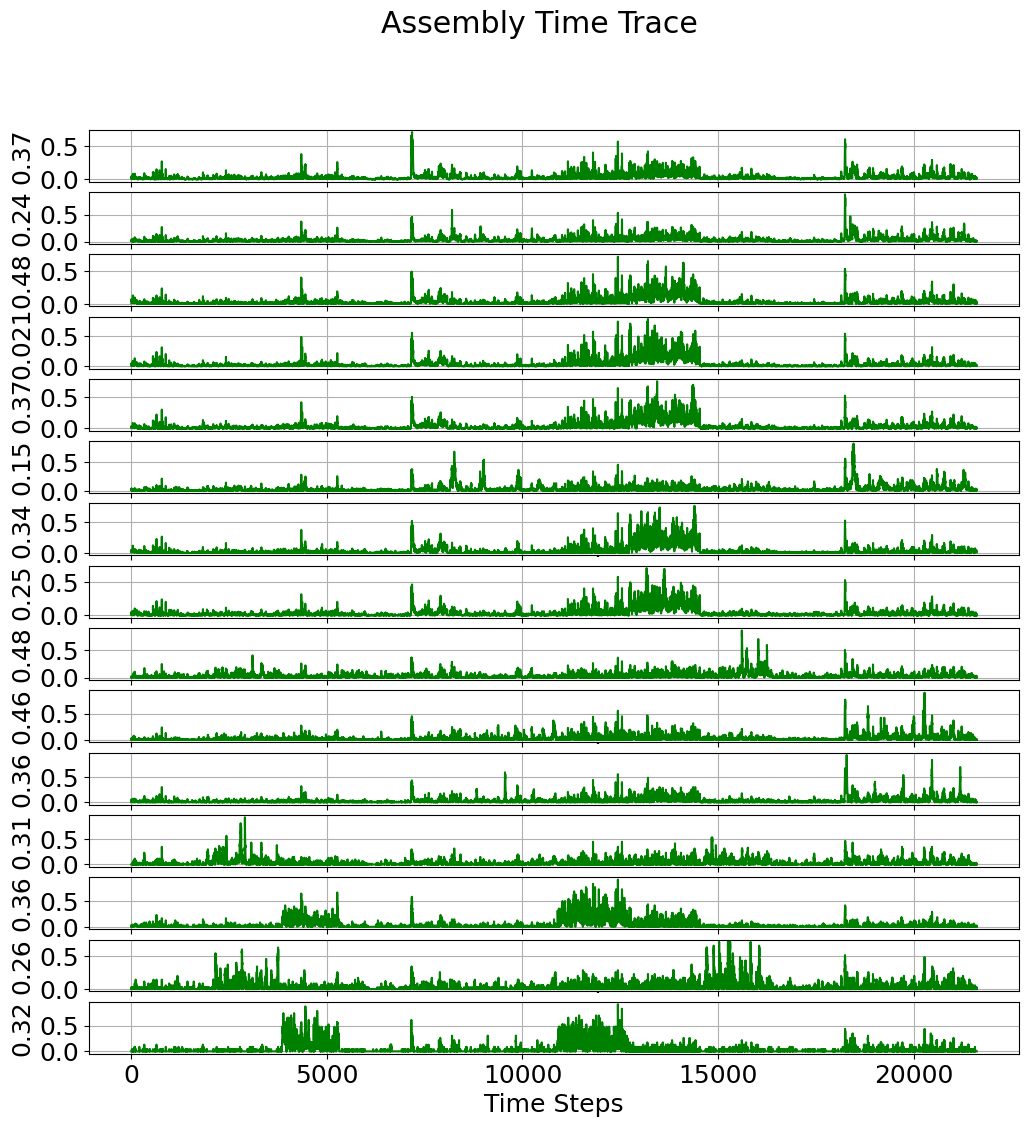

In [3]:
ACTIVITY_RASTER = scipy.io.loadmat(
    "../Figure4/data_files/v1dd/functional/final/session13_ACTIVITY-RASTER.mat", struct_as_record=True, squeeze_me=True)
SGC_ASSEMBLIES = scipy.io.loadmat(
    "./data_files/v1dd/functional/final/esteps_150000_affinity_04_sessionM409828_13_SGC-ASSEMBLIES.mat", struct_as_record=True, squeeze_me=True)

#print(ACTIVITY_RASTER.keys())

activity_raster = ACTIVITY_RASTER['activity_raster']
activity_raster_peaks = ACTIVITY_RASTER['activity_raster_peaks']

coactivity_trace = activity_raster.mean(axis=1)

assemblies = SGC_ASSEMBLIES['assemblies']

# Ensure correct indexing (convert 1-based to 0-based)
assemblies = [np.array(A) - 1 for A in assemblies]
assemblies.sort(key = len)
assemblies.reverse()

# for assembly in assemblies:
#     print(np.max(assembly))
#     print(np.min)

assembly_coactivity_trace = np.vstack(
    [activity_raster[:, A].mean(axis=1) for A in assemblies]).T

scores_in_order = np.load('./data_files/v1dd/functional/final/assemblies_esteps_150000_affinity_04_session13_natural_movie_oracle_scores.npy')
get_assembly_time_trace(assembly_coactivity_trace, scores_in_order)


In [4]:
activity_raster.shape

(21616, 2708)

In [5]:
assemblies[0]

array([  11,   12,   25, ..., 2702, 2705, 2706])

In [6]:

def build_neuron_membership(assemblies, num_neurons):
    """
    Establish neuron to assembly membership. Should match LSMM Data.

    Parameters
    ----------
    assemblies: list of arrays, each containing neuron indices in that assembly.
    num_neurons: total number of neurons (should be same as activity_raster.shape[1])

    Returns
    -------
    neuron_to_assemblies : list of sets
        neuron_to_assemblies[i] = set of assembly IDs that neuron i belongs to.
    """
    neuron_to_assemblies = [set() for _ in range(num_neurons)]
    for a_idx, assembly in enumerate(assemblies):
        for n in assembly:
            neuron_to_assemblies[n].add(a_idx)
    return neuron_to_assemblies


def compute_pairwise_correlations(activity_raster, assemblies):
    """
    Compute pairwise correlations for shared assembly neurons, disjoint assembly neurons, and all neurons.

    Parameters
    ----------
    activity_raster : array, shape (T, N)
        Time x Neurons activity matrix.
    assemblies : list of arrays
        Each element has neuron indices for that assembly.

    Returns
    -------
    shared_corrs, disjoint_corrs, all_corrs : 1D np.ndarrays
    """
    T, num_neurons = activity_raster.shape
    print(f"activity_raster shape: T={T}, N={num_neurons}")

    neuron_to_assemblies = build_neuron_membership(assemblies, num_neurons)

    # Compute full correlation matrix across neurons
    print("Computing correlation matrix.")
    corr_mat = np.corrcoef(activity_raster, rowvar=False)  # shape (N, N)

    shared_corrs = []
    disjoint_corrs = []
    all_corrs = []

    print("Partitioning correlations into shared vs disjoint.")
    for i in range(num_neurons):
        Ai = neuron_to_assemblies[i]
        # slice once to make later computation faster
        row = corr_mat[i, i+1:]
        for offset, c in enumerate(row, start=i+1):
            j = offset
            if not np.isfinite(c):
                continue  # skip NaN or infinite correlations
            all_corrs.append(c) # always add correlation, then split
            Aj = neuron_to_assemblies[j]
            if Ai & Aj:  # if non-empty intersection exists
                shared_corrs.append(c)
            else:
                disjoint_corrs.append(c)

    shared_corrs = np.asarray(shared_corrs, dtype=float)
    disjoint_corrs = np.asarray(disjoint_corrs, dtype=float)
    all_corrs = np.asarray(all_corrs, dtype=float)

    print(f"# shared pairs:   {len(shared_corrs)}")
    print(f"# disjoint pairs: {len(disjoint_corrs)}")
    print(f"# all pairs:      {len(all_corrs)}")

    return shared_corrs, disjoint_corrs, all_corrs


def make_raincloud(shared_corrs, disjoint_corrs, all_corrs,
                   title="Pairwise Correlation Distributions Among Assembly Membership"):
    """
    Make a RainCloud-style plot (shared vs disjoint vs all pairs).

    """
    corr_values = np.concatenate([shared_corrs, disjoint_corrs, all_corrs])
    groups = ([f"Shared\nAssembly\nCells\nn={len(shared_corrs)}"] * len(shared_corrs) +
              [f"Disjoint\nAssembly\nCells\nn={len(disjoint_corrs)}"] * len(disjoint_corrs) +
              [f"All\nCells\nn={len(all_corrs)}"] * len(all_corrs))

    data = pd.DataFrame({"Cell Grouping": groups, "Activity Correlation": corr_values})

    # Create a figure
    plt.figure(figsize=(12,8))
    sns.set_theme(style="whitegrid")
    ax = pt.RainCloud(
            x="Cell Grouping",
            y="Activity Correlation",
            data=data,
            palette=[(.4, .6, .8, .5), 'grey'],
            width_viol=0.6,  # Adjust violin width
            alpha=0.8,  # Transparency of the cloud
            move=0.1,  # Adjust position of violins
            point_size = 6,
            orient="v",  # Horizontal orientation
            linewidth=2
            )

    ax.set_title(title, size = 20)
    ax.set_ylabel("Pairwise Pearson correlation", size = 18)
    ax.set_xlabel("Correlation (r)", size = 18)
    ax.tick_params(axis='both', labelsize=16)
    plt.tight_layout()

    plt.ylim(-0.1, 1) 

    # # Add significance stars
    for p_index, p_value in enumerate([0,0]):
        if p_value < 0.001:
            significance = 'P < 0.001\n***'
        elif p_value < 0.01:
            significance = 'P < 0.01\n**'
        elif p_value < 0.05:
            significance = 'P < 0.05\n*'
        else:
            significance = 'ns'

        # Add p-value annotation
        if p_index == 0:
            p_offset = 0.5
            p_height = .9
        elif p_index > 0 and p_index < 4:
            p_offset = 0.5 + p_index
            p_height = .9
        elif p_index == 4:
            p_offset = 2.5
            p_height = 0.5
        elif p_index == 5:
            p_offset = 3.5
            p_height = 0.5

        ax.text(p_offset, p_height, f'{significance}', 
                    color='black', ha='center', va='bottom', fontsize=16, weight='bold')
        
    plt.show()


In [7]:
shared_corrs, disjoint_corrs, all_corrs = compute_pairwise_correlations(
    activity_raster,
    assemblies
)

activity_raster shape: T=21616, N=2708
Computing correlation matrix.
Partitioning correlations into shared vs disjoint.
# shared pairs:   771835
# disjoint pairs: 2893443
# all pairs:      3665278


In [8]:
print("means:", np.mean(shared_corrs), np.mean(disjoint_corrs), np.mean(all_corrs))
print("medians:", np.median(shared_corrs), np.median(disjoint_corrs), np.median(all_corrs))

means: 0.06870643152221956 0.03673845179293427 0.04347027558211281
medians: 0.06292443979368748 0.034532283901456455 0.039956435423060724


In [9]:
print(stats.ranksums(shared_corrs, all_corrs))
print(stats.ranksums(shared_corrs, disjoint_corrs))


RanksumsResult(statistic=525.6541205090492, pvalue=0.0)
RanksumsResult(statistic=650.9428209797467, pvalue=0.0)


/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:779: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


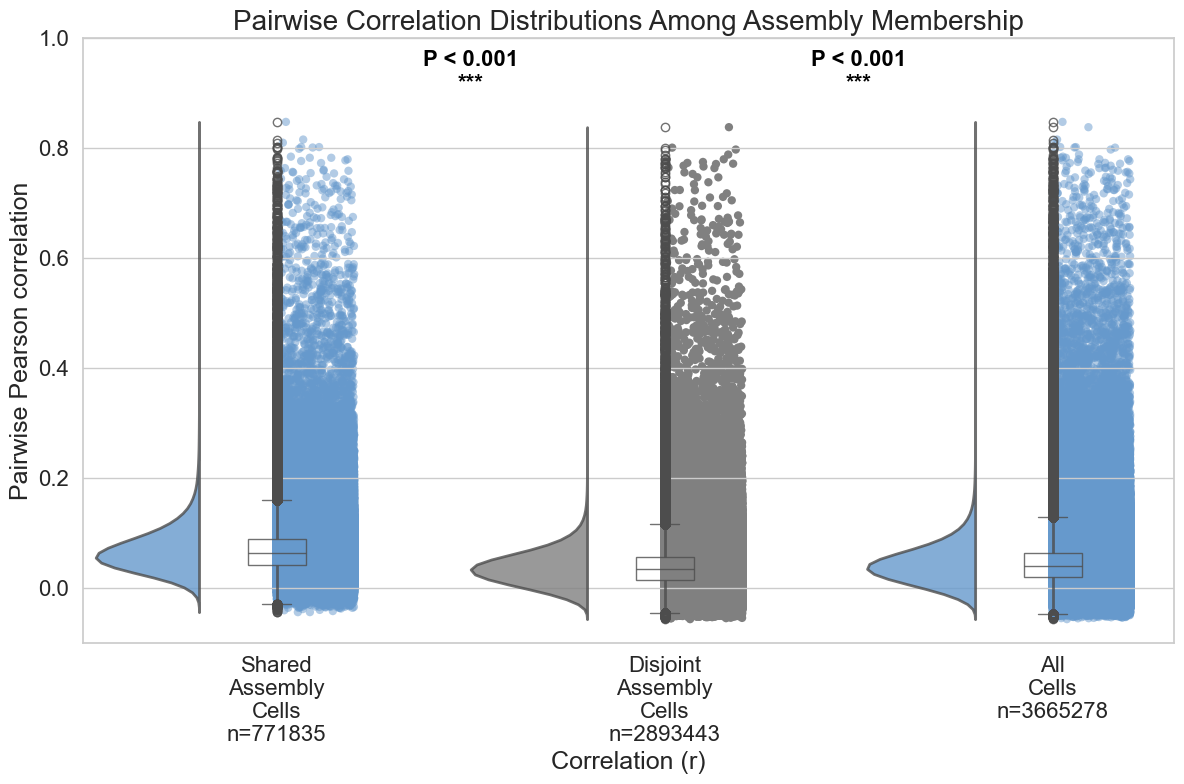

In [12]:
make_raincloud(shared_corrs, disjoint_corrs, all_corrs)

### Work on Noise Correlations

In [10]:
assembly_coactivity_trace = np.vstack(
    [activity_raster[:, A-1].mean(axis=1) for A in assemblies]).T
assembly_mapping = pd.read_pickle('../Figure2/map_ordered_to_sgc_output.pickle')

In [11]:
T, N = activity_raster.shape
print(f"Activity raster shape: T={T}, N={N}, n_assemblies={len(assemblies)}")

Activity raster shape: T=21616, N=2708, n_assemblies=15


In [12]:
nwb_f = h5py.File('./data_files/v1dd/functional/final/M409828_13_20181213.nwb', 'r')
presentation = nwb_f['stimulus']['presentation']

In [13]:
nm_timestamps = np.array(presentation['natural_movie'].get('timestamps'))
nm_data = np.array(presentation['natural_movie'].get('data'))
noise_timestamps = np.array(presentation['locally_sparse_noise'].get('timestamps'))
noise_data = np.array(presentation['locally_sparse_noise'].get('data'))

In [14]:
np.unique(nm_data[:,2], return_inverse = True)

(array([0.000e+00, 1.000e+00, 2.000e+00, ..., 3.597e+03, 3.598e+03,
        3.599e+03], dtype=float32),
 array([  0,   1,   2, ..., 897, 898, 899]))

In [15]:
assembly_timesteps = np.load('./data_files/v1dd/functional/final/sessionM409828_13_f_ts.npy')
assembly_timesteps_start = assembly_timesteps[0]
assembly_timesteps_end = assembly_timesteps[-1]

frame_ts = assembly_timesteps

In [16]:
def build_stim_response_matrix(activity, frame_ts, stim_data):
    """
    Build response matrix [stimulus x trial x neuron] from activity.

    Parameters
    ----------
        activity: (T, N) array (for neurons)
        frame_ts: (T,) timestamps of imaging frames
        stim_data: (P, 3): [start_time, end_time, stim_id]

    Returns
    ----------
        responses: (S, R_max, N) with NaNs for missing trials
        stim_ids: (S,) unique stimulus IDs
        trial_counts: (S,) number of valid trials per stimulus
    """
    T, N = activity.shape
    starts = stim_data[:, 0]
    ends = stim_data[:, 1]
    ids = stim_data[:, 2].astype(int)

    stim_ids, inv = np.unique(ids, return_inverse=True)  # map each row -> condition index
    S = len(stim_ids)

    trial_counts = np.bincount(inv, minlength=S)
    R_max = trial_counts.max()

    responses = np.full((S, R_max, N), np.nan, dtype=float)
    trial_counter = np.zeros(S, dtype=int)

    for p in range(len(stim_data)):
        s_idx = inv[p]
        r_idx = trial_counter[s_idx]

        t_mask = (frame_ts >= starts[p]) & (frame_ts <= ends[p]) # imaging frames in this stimulus window
        if not np.any(t_mask):
            continue

        resp = activity[t_mask, :].mean(axis=0)  # (N,)
        responses[s_idx, r_idx, :] = resp
        trial_counter[s_idx] += 1

    # update trial counts to only include what overlaps with imaging
    trial_counts = trial_counter.copy()
    
    return responses, stim_ids, trial_counts

In [17]:
# Build stimulus-response matrices for NEURONS
nm_neuron_resp, nm_ids, nm_trial_counts = build_stim_response_matrix(
    activity_raster, frame_ts, nm_data
)
noise_neuron_resp, noise_ids, noise_trial_counts = build_stim_response_matrix(
    activity_raster, frame_ts, noise_data
)

In [18]:
nm_neuron_resp.shape, noise_neuron_resp.shape

((3600, 9, 2708), (1593, 2, 2708))

In [19]:
def compute_signal_noise_corr(responses, trial_counts):
    """
    Compute signal and noise correlation matrices from response matrix.

    Parameters
    ----------
        responses: (S, R_max, N) with NaNs for missing trials
        trial_counts: (S,) number of valid trials per stimulus

    Returns
    ----------
        signal_corr: (N, N) correlation of tuning curves across stimuli
        noise_corr: (N, N) correlation of residuals across (stim, trial)
    """
    S, R_max, N = responses.shape

    # Valid trial mask: true where all neurons are finite
    valid_mask = np.isfinite(responses).all(axis=2)  # (S, R_max)

    # Signal computation
    tuning = np.full((S, N), np.nan)
    for s in range(S):
        if trial_counts[s] == 0:
            continue
        trials_s = valid_mask[s]
        if not np.any(trials_s):
            continue
        tuning[s, :] = responses[s, trials_s, :].mean(axis=0)

    good_stim = np.isfinite(tuning).all(axis=1)
    tuning_good = tuning[good_stim, :]
    if tuning_good.shape[0] < 2:
        raise RuntimeError("Not enough stimuli with valid responses to compute signal correlations.")

    signal_corr = np.corrcoef(tuning_good, rowvar=False)  # (N, N)

    # Residual (noise) computation
    residual_list = []
    for s in range(S):
        if trial_counts[s] < 2:
            continue
        if not np.isfinite(tuning[s, :]).all():
            continue
        trials_s = valid_mask[s]
        if trials_s.sum() < 2:
            continue
        resp_s = responses[s, trials_s, :]       # (n_trials_s, N)
        resid_s = resp_s - tuning[s, :]          # broadcast over trials
        residual_list.append(resid_s)

    if len(residual_list) == 0:
        print("Warning: no stimuli with >=2 valid trials; noise correlations will be NaN.")
        noise_corr = np.full_like(signal_corr, np.nan, dtype=float)
    else:
        all_resid = np.vstack(residual_list)      # (M, N)
        noise_corr = np.corrcoef(all_resid, rowvar=False)

    return signal_corr, noise_corr


def extract_pairwise_corrs(corr_mat, neuron_to_assemblies):
    """
    Flatten correlation matrix into distributions for all cell pairs, shared assembly pairs, and disjoint assemlby pairs.

    Parameters
    ----------
        corr_mat: (N, N)
        neuron_to_assemblies: list of sets, len N

    Returns
    ----------
        dict with keys referring to all the correlation values
    """
    N = corr_mat.shape[0]
    all_vals = []
    shared_vals = []
    disjoint_vals = []

    for i in range(N):
        Ai = neuron_to_assemblies[i]
        row = corr_mat[i, i+1:]
        for offset, c in enumerate(row, start=i+1):
            j = offset
            if not np.isfinite(c):
                continue
            all_vals.append(c)
            Aj = neuron_to_assemblies[j]
            if Ai & Aj:
                shared_vals.append(c)
            else:
                disjoint_vals.append(c)

    # all_vals = np.asarray(all_vals, float)
    shared_vals = np.asarray(shared_vals, float)
    disjoint_vals = np.asarray(disjoint_vals, float)

    return {f"All\nCells\n(n={len(all_vals)})": all_vals, f"Shared\nAssembly\nCells\n(n={len(shared_vals)})": shared_vals, f"Disjoint\nAssembly\nCells\n(n={len(disjoint_vals)})": disjoint_vals}

In [20]:
print("Computing NEURON-LEVEL correlations for natural_movie...")
nm_signal_corr, nm_noise_corr = compute_signal_noise_corr(
    nm_neuron_resp, nm_trial_counts
)
print(f"\t\t\tDONE WITH NATURAL MOVIES.")
print("Computing NEURON-LEVEL correlations for locally_sparse_noise...")
lsn_signal_corr, lsn_noise_corr = compute_signal_noise_corr(
    noise_neuron_resp, noise_trial_counts
)
print(f"\t\t\tDONE WITH NOISE.")

Computing NEURON-LEVEL correlations for natural_movie...


/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


			DONE WITH NATURAL MOVIES.
Computing NEURON-LEVEL correlations for locally_sparse_noise...
			DONE WITH NOISE.


In [21]:
neuron_to_assemblies = build_neuron_membership(assemblies, N)
print("These many neurons are found in no assemlbies:", len(np.where(np.array(neuron_to_assemblies) == set())[0]))

These many neurons are found in no assemlbies: 748


In [22]:
nm_signal_pairs = extract_pairwise_corrs(
        nm_signal_corr, neuron_to_assemblies,
)
nm_noise_pairs = extract_pairwise_corrs(
    nm_noise_corr, neuron_to_assemblies,
)

lsn_signal_pairs = extract_pairwise_corrs(
    lsn_signal_corr, neuron_to_assemblies,
)
lsn_noise_pairs = extract_pairwise_corrs(
    lsn_noise_corr, neuron_to_assemblies,
)

In [23]:
def plot_raincloud_pairwise(df, stim_label, save_figure = False):
    """
    Make a RainCloud-style plot of pairwise correlations for the given stimulus type.

    Parameters
    ----------
    df: DataFrame with columns:
        'stim', 'corr_type' ('signal'/'noise'),
        'pair_type' ('all'/'shared'/'disjoint'), 'corr'
    stim_label: 'natural_movie' or 'locally_sparse_noise'
    """
    sns.set_theme(style="whitegrid")
    sub = df[df["stim"] == stim_label].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
    for ax, ctype in zip(axes, ["signal", "noise"]):
        sub_c = sub[sub["corr_type"] == ctype]
        if len(sub_c) == 0:
            ax.text(0.5, 0.5, f"No data for {ctype}", ha="center", va="center")
            ax.set_axis_off()
            continue

        pt.RainCloud(
            x="pair_type",
            y="corr",
            data=sub_c,
            palette=[(.4, .6, .8, .5)],
            ax=ax,
            width_viol=0.4,
            width_box=0.3,
            move=0.2,
            alpha=0.7,
            pointplot=True)

        ax.set_title(f"{stim_label} – {ctype} correlations", size = 20)
        ax.set_xlabel("Pair Type", size = 18)
        ax.set_ylabel("Pairwise Pearson correlation" if ctype == "signal" else "", size = 18)
        ax.tick_params(axis='both', labelsize=16)

        # Rasterize all scatter-like collections (stripplot / swarm / point clouds)
        for coll in ax.collections:
            coll.set_rasterized(True)

        # # Add significance stars
        for p_index, p_value in enumerate([0]):
            if p_value < 0.001:
                significance = 'P < 0.001\n***'
            elif p_value < 0.01:
                significance = 'P < 0.01\n**'
            elif p_value < 0.05:
                significance = 'P < 0.05\n*'
            else:
                significance = 'ns'

            # Add p-value annotation
            if p_index == 0:
                p_offset = 0.5
                p_height = 1
            elif p_index > 0 and p_index < 4:
                p_offset = 0.5 + p_index
                p_height = 1
            elif p_index == 4:
                p_offset = 2.5
                p_height = 0.5
            elif p_index == 5:
                p_offset = 3.5
                p_height = 0.5

            ax.text(p_offset, p_height, f'{significance}', 
                        color='black', ha='center', va='bottom', fontsize=16, weight='bold')

    if stim_label == 'natural_movie':
        stim_title = 'Natural Movies'
    else:
        stim_title = 'White Noise'

    fig.suptitle(f"Pairwise Signal vs Noise correlations Among Assembly Membership ({stim_title})", y=1.01, size = 18)
    plt.ylim(None, 1.19)
    plt.tight_layout()

    if save_figure:
        plt.savefig(f'./draft_figures/Signal_vs_Noise_Correlations_{stim_label}.pdf', bbox_inches="tight")

    plt.show()

In [34]:
# build a long records dictionary for all the data
records = []

def add_records(stim_label, corr_type, pair_dict):
    for ptype, vals in pair_dict.items():
        for v in vals:
            records.append(
                {
                    "stim": stim_label,
                    "corr_type": corr_type,
                    "pair_type": ptype,
                    "corr": float(v),
                }
            )

add_records("natural_movie", "signal", nm_signal_pairs)
add_records("natural_movie", "noise", nm_noise_pairs)
add_records("locally_sparse_noise", "signal", lsn_signal_pairs)
add_records("locally_sparse_noise", "noise", lsn_noise_pairs)

df_pairs = pd.DataFrame.from_records(records)

def subsample_df(df, n_per_group=20000, seed=747):
    KEEP_PREFIXES = ("Disjoint\nAssembly\nCells", "Shared\nAssembly\nCells")
    mask = df["pair_type"].astype(str).str.startswith(KEEP_PREFIXES)
    df_filt = df.loc[mask].copy()

    df_plot = (
        df_filt
        .groupby(["stim", "corr_type", "pair_type"], group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), n_per_group), random_state=seed))
        .reset_index(drop=True)
    )
    return df_plot

df_plot = subsample_df(df_pairs, n_per_group=350000)

print(df_pairs.groupby(["stim", "corr_type", "pair_type"]).size())
print(df_plot.groupby(["stim", "corr_type", "pair_type"]).size())

/var/folders/pf/3jc_0npn76z9n_c1pvb23kp00000gn/T/ipykernel_53142/3398304735.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), n_per_group), random_state=seed))


stim                  corr_type  pair_type                             
locally_sparse_noise  noise      All\nCells\n(n=3265290)                   3265290
                                 Disjoint\nAssembly\nCells\n(n=2552586)    2552586
                                 Shared\nAssembly\nCells\n(n=712704)        712704
                      signal     All\nCells\n(n=3638253)                   3638253
                                 Disjoint\nAssembly\nCells\n(n=2868198)    2868198
                                 Shared\nAssembly\nCells\n(n=770055)        770055
natural_movie         noise      All\nCells\n(n=3643650)                   3643650
                                 Disjoint\nAssembly\nCells\n(n=2877703)    2877703
                                 Shared\nAssembly\nCells\n(n=765947)        765947
                      signal     All\nCells\n(n=3659865)                   3659865
                                 Disjoint\nAssembly\nCells\n(n=2888745)    2888745
               

/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:779: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1143: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.0}` instead.

  sns.pointplot(
/opt/anacon

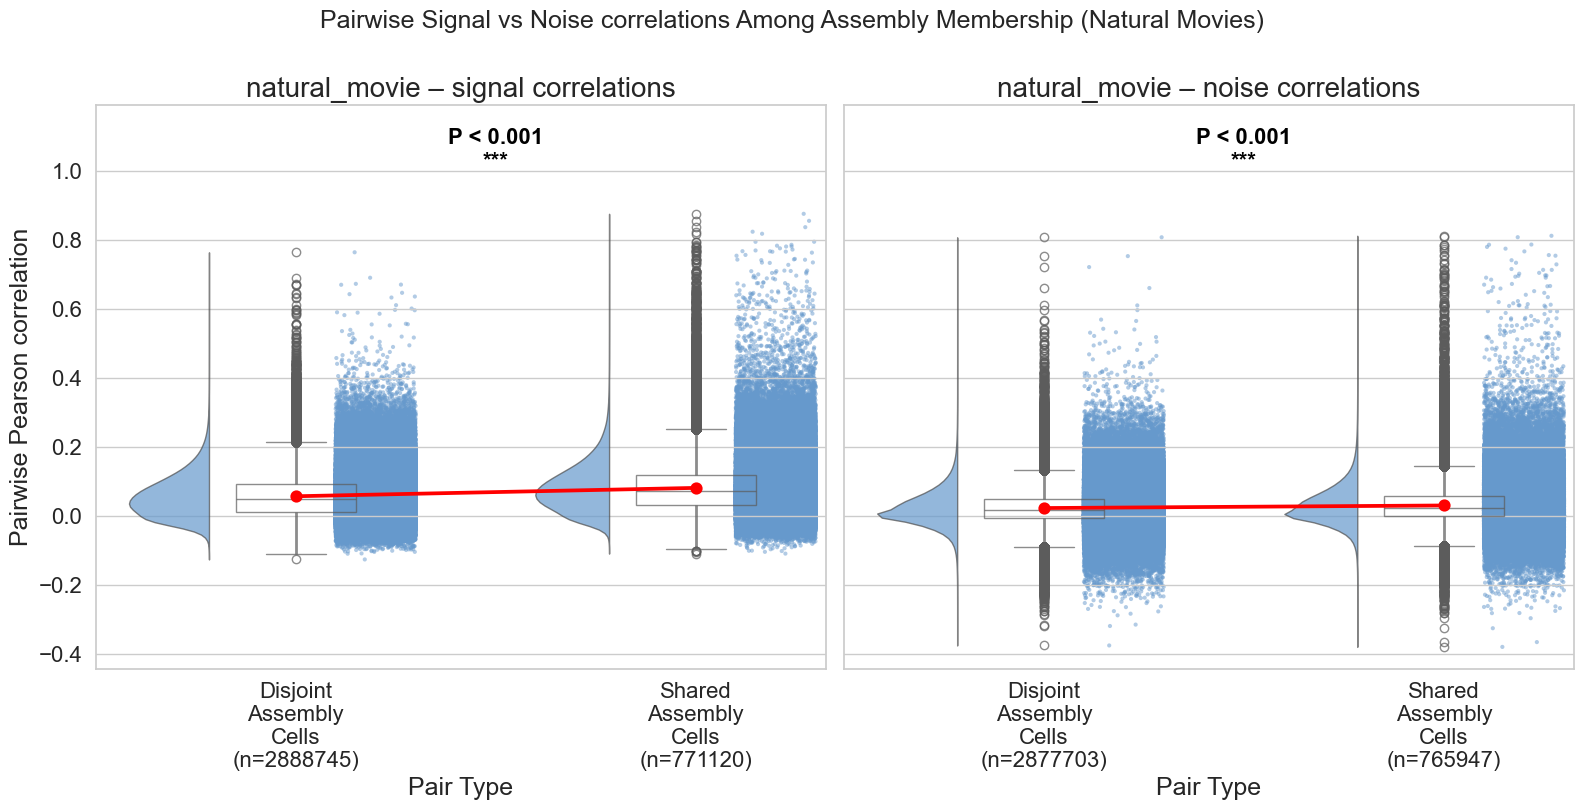

In [35]:
plot_raincloud_pairwise(df_plot, "natural_movie", save_figure = True)

/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:779: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1143: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.0}` instead.

  sns.pointplot(
/opt/anacon

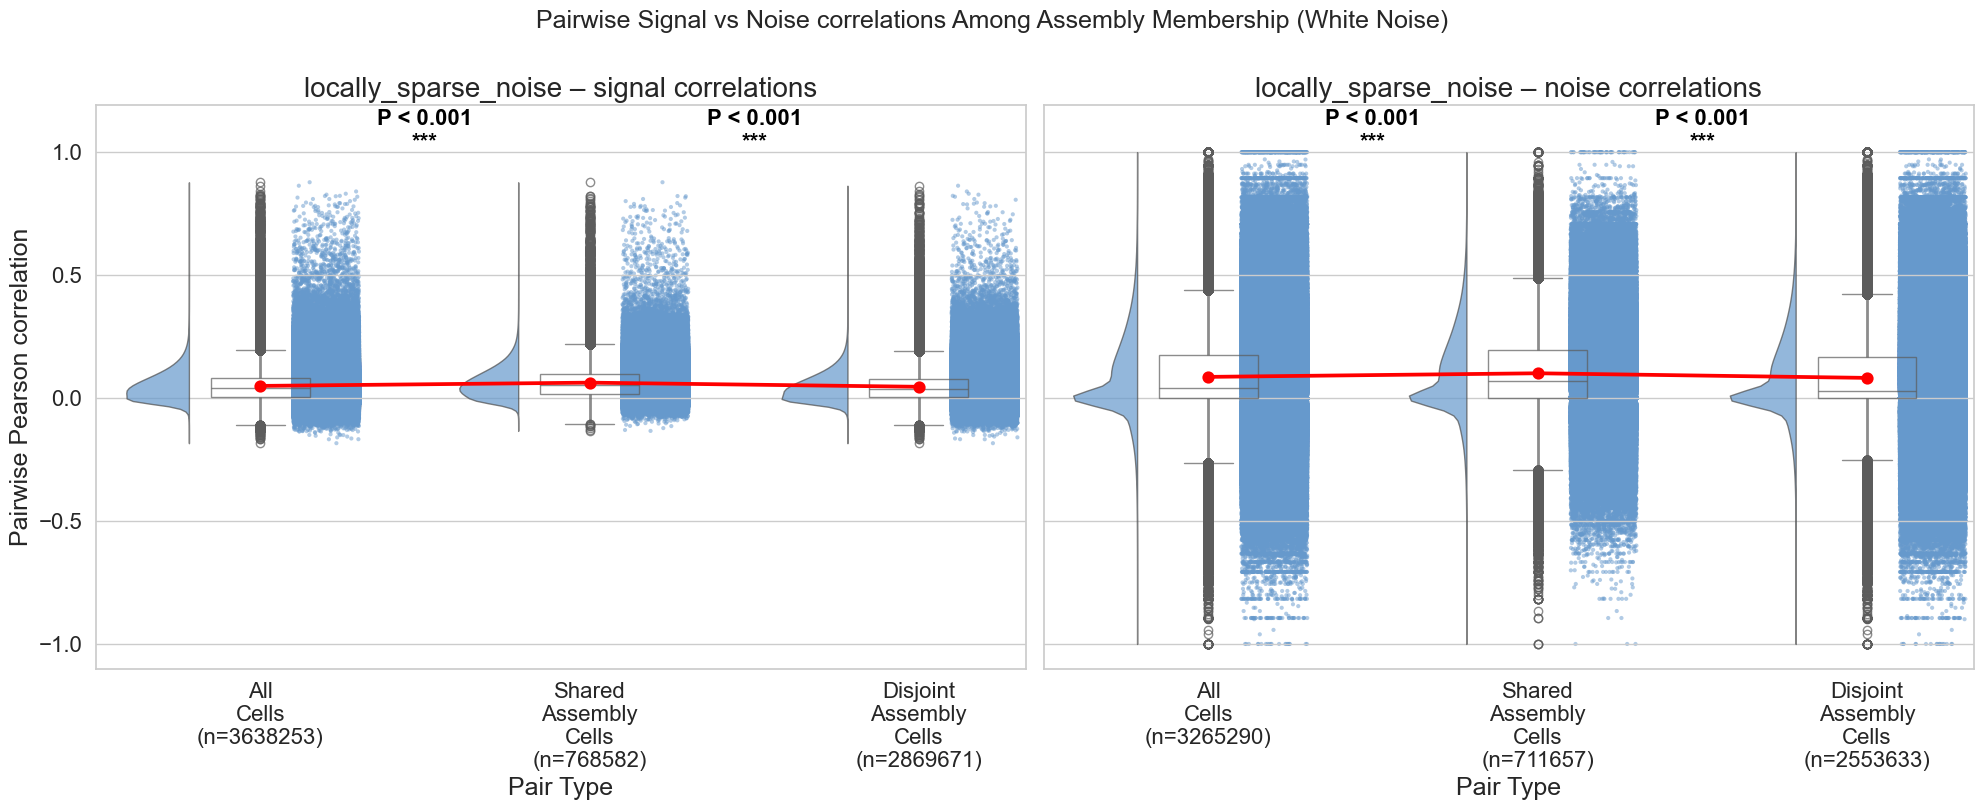

In [27]:
plot_raincloud_pairwise(df_pairs, "locally_sparse_noise")

In [28]:
df_pairs

,stim,corr_type,pair_type,corr
0,natural_movie,signal,All\nCells\n(n=3659865),0.602952
1,natural_movie,signal,All\nCells\n(n=3659865),-0.078579
2,natural_movie,signal,All\nCells\n(n=3659865),0.137117
3,natural_movie,signal,All\nCells\n(n=3659865),-0.033611
4,natural_movie,signal,All\nCells\n(n=3659865),-0.121053
...,...,...,...,...
28414111,locally_sparse_noise,noise,Disjoint\nAssembly\nCells\n(n=2552586),-0.136931
28414112,locally_sparse_noise,noise,Disjoint\nAssembly\nCells\n(n=2552586),-0.138675
28414113,locally_sparse_noise,noise,Disjoint\nAssembly\nCells\n(n=2552586),0.158114
28414114,locally_sparse_noise,noise,Disjoint\nAssembly\nCells\n(n=2552586),-0.080064


In [29]:
np.unique(df_pairs['pair_type'].values)[0]

'All\nCells\n(n=3265290)'

In [30]:
sub = df_pairs[(df_pairs["stim"] == "natural_movie") &
                   (df_pairs["corr_type"] == "signal")].copy()


In [31]:
np.unique(sub['pair_type'].values)

array(['All\nCells\n(n=3659865)',
       'Disjoint\nAssembly\nCells\n(n=2888745)',
       'Shared\nAssembly\nCells\n(n=771120)'], dtype=object)

In [32]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# def bh_fdr(pvals, alpha=0.05):
#     pvals = np.asarray(pvals, float)
#     m = len(pvals)
#     order = np.argsort(pvals)
#     ranked_p = pvals[order]

#     # BH: p_(i) * m / i
#     q = ranked_p * m / np.arange(1, m+1)
#     # enforce monotonicity
#     q = np.minimum.accumulate(q[::-1])[::-1]
#     pvals_corrected = np.empty_like(q)
#     pvals_corrected[order] = q
#     reject = pvals_corrected <= alpha
#     return reject, pvals_corrected

def pairwise_mwu_for_stim(df_pairs, stim_label, corr_type,
                          subsample_per_group=None, random_state=0):
    """
    Run pairwise Mann-Whitney U tests on correlation distributions for a given
    stimulus and correlation type.

    df_pairs: DataFrame with columns 'stim', 'corr_type', 'pair_type', 'corr'
    stim_label: e.g. "natural_movie"
    corr_type: "signal" or "noise"
    subsample_per_group: int or None (optional extra thinning)
    """
    rng = np.random.default_rng(random_state)

    sub = df_pairs[(df_pairs["stim"] == stim_label) &
                   (df_pairs["corr_type"] == corr_type)].copy()

    group_vals = {}
    # pairs_type = ["All Cells ***", "Disjoint Assembly ***","Shared Assembly ***"]
    pairs_type = np.unique(sub['pair_type'].values)
    for ptype in pairs_type:
        arr = sub.loc[sub["pair_type"] == ptype, "corr"].to_numpy()
        if subsample_per_group is not None and len(arr) > subsample_per_group:
            idx = rng.choice(len(arr), size=subsample_per_group, replace=False)
            arr = arr[idx]
        group_vals[ptype] = arr

    # Defining the comparisons that will be run
    comparisons = [
        (pairs_type[0], pairs_type[1]),
        (pairs_type[0], pairs_type[2]),
        (pairs_type[2], pairs_type[1]),
    ]

    results = []
    raw_pvals = []

    for g1, g2 in comparisons:
        x = group_vals[g1]
        y = group_vals[g2]
        n1, n2 = len(x), len(y)
        if n1 == 0 or n2 == 0:
            print(f"Skipping {g1} vs {g2} for {stim_label}, {corr_type}: empty group.")
            continue

        # Statistical Test
        U, p = mannwhitneyu(x, y, alternative="two-sided", method="asymptotic")
        raw_pvals.append(p)

        # Effect size
        med_diff = np.median(x) - np.median(y)
        # rank-biserial correlation
        r_rb = 2.0 * U / (n1 * n2) - 1.0

        results.append({
            "stim": stim_label,
            "corr_type": corr_type,
            "group1": g1,
            "group2": g2,
            "n1": n1,
            "n2": n2,
            "U": U,
            "p_raw": p,
            "median_diff": med_diff,
            "rank_biserial": r_rb,
        })

    # FDR correction across comparisons
    if len(raw_pvals) > 0:
        _, p_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method="fdr_bh")
        for res, p_corr in zip(results, p_corrected):
            res["p_fdr"] = p_corr

    return pd.DataFrame(results)

In [33]:
# Natural movie signal correlations
nm_sig_res = pairwise_mwu_for_stim(df_pairs,
                                   stim_label="natural_movie",
                                   corr_type="signal",
                                   subsample_per_group=None)

# Natural movie noise correlations
nm_noise_res = pairwise_mwu_for_stim(df_pairs,
                                     stim_label="natural_movie",
                                     corr_type="noise",
                                     subsample_per_group=None)

print("Natural movie – signal:")
print(nm_sig_res)

print("\nNatural movie – noise:")
print(nm_noise_res)

Natural movie – signal:
            stim corr_type                               group1  \
0  natural_movie    signal              All\nCells\n(n=3659865)   
1  natural_movie    signal              All\nCells\n(n=3659865)   
2  natural_movie    signal  Shared\nAssembly\nCells\n(n=771120)   

                                   group2       n1       n2             U  \
0  Disjoint\nAssembly\nCells\n(n=2888745)  3659865  2888745  5.521158e+12   
1     Shared\nAssembly\nCells\n(n=771120)  3659865   771120  1.176148e+12   
2  Disjoint\nAssembly\nCells\n(n=2888745)   771120  2888745  1.348734e+12   

   p_raw  median_diff  rank_biserial  p_fdr  
0    0.0     0.004838       0.044446    0.0  
1    0.0    -0.019032      -0.166501    0.0  
2    0.0     0.023869       0.210947    0.0  

Natural movie – noise:
            stim corr_type                               group1  \
0  natural_movie     noise              All\nCells\n(n=3643650)   
1  natural_movie     noise              All\nCells\n(n=3

In [34]:
# Natural movie signal correlations
nm_sig_res = pairwise_mwu_for_stim(df_pairs,
                                   stim_label="locally_sparse_noise",
                                   corr_type="signal",
                                   subsample_per_group=None)

# Natural movie noise correlations
nm_noise_res = pairwise_mwu_for_stim(df_pairs,
                                     stim_label="locally_sparse_noise",
                                     corr_type="noise",
                                     subsample_per_group=None)

print("Locally Sparse Noise – signal:")
print(nm_sig_res)

print("\nLocally Sparse Noise – noise:")
print(nm_noise_res)

Locally Sparse Noise – signal:
                   stim corr_type                               group1  \
0  locally_sparse_noise    signal              All\nCells\n(n=3638253)   
1  locally_sparse_noise    signal              All\nCells\n(n=3638253)   
2  locally_sparse_noise    signal  Shared\nAssembly\nCells\n(n=768582)   

                                   group2       n1       n2             U  \
0  Disjoint\nAssembly\nCells\n(n=2869671)  3638253  2869671  5.402535e+12   
1     Shared\nAssembly\nCells\n(n=768582)  3638253   768582  1.215907e+12   
2  Disjoint\nAssembly\nCells\n(n=2869671)   768582  2869671  1.285029e+12   

   p_raw  median_diff  rank_biserial  p_fdr  
0    0.0     0.003386       0.034910    0.0  
1    0.0    -0.013369      -0.130344    0.0  
2    0.0     0.016755       0.165254    0.0  

Locally Sparse Noise – noise:
                   stim corr_type                               group1  \
0  locally_sparse_noise     noise              All\nCells\n(n=3265290)   


### Offsemble Analysis

In [2]:
ACTIVITY_RASTER = scipy.io.loadmat(
    "./data_files/v1dd/functional/final/session13_ACTIVITY-RASTER.mat", struct_as_record=True, squeeze_me=True)
SGC_ASSEMBLIES = scipy.io.loadmat(
    "./data_files/v1dd/functional/final/esteps_150000_affinity_04_sessionM409828_13_SGC-ASSEMBLIES.mat", struct_as_record=True, squeeze_me=True)

#print(ACTIVITY_RASTER.keys())

activity_raster = ACTIVITY_RASTER['activity_raster']
activity_raster_peaks = ACTIVITY_RASTER['activity_raster_peaks']

coactivity_trace = activity_raster.mean(axis=1)

assemblies = SGC_ASSEMBLIES['assemblies']

# Ensure correct indexing (convert 1-based to 0-based)
assemblies = [np.array(A) - 1 for A in assemblies]
assemblies.sort(key = len)
assemblies.reverse()

# for assembly in assemblies:
#     print(np.max(assembly))
#     print(np.min)

assembly_coactivity_trace = np.vstack(
    [activity_raster[:, A].mean(axis=1) for A in assemblies]).T

In [3]:
def compute_epi_and_offsembles(
    activity_raster,                 # (T, N) binary or nonnegative
    assembly_coactivity_trace,       # (T, K)
    q_on=0.95,                       # top 5% frames define "assembly on"
    min_fr_total=1e-4,               # exclude near-silent neurons
    n_perm=500,                      # increase to 1000+ if you want
    rng_seed=747,
):
    T, N = activity_raster.shape
    T2, K = assembly_coactivity_trace.shape
    assert T == T2 # making sure they have the same traces
    X = activity_raster.astype(np.float32)
    A = assembly_coactivity_trace.astype(np.float32)

    # Total activity per neuron, proxy for firing rate
    fr_total = X.mean(axis=0)  # (N,)
    valid = fr_total >= min_fr_total
    eps = 1e-12 # an epsiolon to allow non-valid neurons, however there shouldn't be any

    # Define "assembly on" masks by per-assembly quantile threshold
    thr = np.quantile(A, q_on, axis=0)              # (K,)
    on_masks = A >= thr[None, :]                    # (T, K), boolean
    n_on = on_masks.sum(axis=0)                     # (K,)
    if np.any(n_on < 10):
        raise ValueError(f"Some assemblies aren't 'on' enough, current frames: {n_on}")

    # Compute FR_ens for every neuron and assembly: mean activity during on-frames
    fr_ens = np.zeros((N, K), dtype=np.float32)
    for e in range(K):
        fr_ens[:, e] = X[on_masks[:, e], :].mean(axis=0) # for each assembly e, average X[on_e] over time

    # EPI: neurons x assemblies
    epi = 2.0 * (fr_ens / (fr_total[:, None] + eps)) - 1.0
    epi[~valid, :] = np.nan  # mark invalid neurons

    # Preferred inactivating condition per neuron = most negative EPI
    pref_off_assembly = np.nanargmin(epi, axis=1)   # (N,)
    epi_min = np.nanmin(epi, axis=1)                # (N,)

    ### Apply a permutation test to see if neuron i is suppressed during the preferred off assembly
    # We'll test, for each neuron i:
    #   delta_i = mean(X during on_e*) - mean(X during off_e*)
    # Offsemble-like neurons should have delta_i < 0
    rng = np.random.default_rng(rng_seed)

    delta_obs = np.full(N, np.nan, dtype=np.float32)
    pvals = np.full(N, np.nan, dtype=np.float32)

    for i in range(N):
        if not valid[i]:
            continue
        e = int(pref_off_assembly[i])
        mask = on_masks[:, e]
        x = X[:, i]

        mu_on = x[mask].mean()
        mu_off = x[~mask].mean()
        delta = mu_on - mu_off
        delta_obs[i] = delta

        # circular-shift null to preserve temporal autocorrelation
        deltas_null = np.empty(n_perm, dtype=np.float32)
        for p in range(n_perm):
            shift = rng.integers(0, T)
            mask_shift = np.roll(mask, shift)
            deltas_null[p] = x[mask_shift].mean() - x[~mask_shift].mean()

        # one-sided p-value for "suppressed": delta_obs is unusually small
        pvals[i] = (np.sum(deltas_null <= delta) + 1) / (n_perm + 1)

    # Simple offsemble candidate rule (tune thresholds to taste)
    # - prefers strong negative epi
    # - shows significant suppression (p < 0.05)
    offsemble_candidate = (epi_min < -0.2) & (pvals < 0.05) & valid

    return {
        "epi": epi,                              # (N, K)
        "fr_total": fr_total,                    # (N,)
        "fr_ens": fr_ens,                        # (N, K)
        "on_masks": on_masks,                    # (T, K)
        "pref_off_assembly": pref_off_assembly,  # (N,)
        "epi_min": epi_min,                      # (N,)
        "delta_obs": delta_obs,                  # (N,)
        "pvals_suppression": pvals,              # (N,)
        "offsemble_candidate": offsemble_candidate, # (N,)
        "valid_neuron": valid,                   # (N,)
    }

epi_and_offsembles = compute_epi_and_offsembles(
                        activity_raster=activity_raster,
                        assembly_coactivity_trace= assembly_coactivity_trace,
                        q_on= 0.95,
                        min_fr_total = 1e-4,
                        n_perm = 500
)


In [4]:
offsemble_candidates = np.where(epi_and_offsembles["offsemble_candidate"])

In [5]:
np.shape(epi_and_offsembles["offsemble_candidate"])

(2708,)

In [6]:
for i in offsemble_candidates:
    print(epi_and_offsembles["pref_off_assembly"][i])

[ 5 12 12 14  3 14 12 12 14 12  7 12 14 14  6  2 12  4 12 12  2 14 12 14
  9 12 12]


In [7]:
np.where(epi_and_offsembles["epi_min"] < -0.2) 

(array([   3,    5,    6,    8,   12,   14,   23,  105,  410,  413,  416,
         419,  426,  430,  432,  433,  434,  435,  439,  440,  441,  447,
         463,  477,  478,  482,  511,  512,  524,  539,  631,  882,  883,
         887,  888,  891,  896,  897,  900,  901,  903,  904,  911,  913,
         915,  916,  921,  924,  928,  941,  946,  952,  962,  963,  969,
         973,  982,  985,  986, 1010, 1020, 1023, 1038, 1064, 1089, 1115,
        1139, 1187, 1363, 1367, 1371, 1373, 1374, 1376, 1379, 1384, 1385,
        1387, 1392, 1407, 1410, 1411, 1412, 1415, 1420, 1424, 1438, 1466,
        1492, 1543, 1561, 1605, 1841, 1843, 1844, 1845, 1848, 1851, 1855,
        1869, 1876, 1894, 1906, 1915, 1925, 1931, 1949, 1963, 2070, 2280,
        2285, 2287, 2292, 2299, 2300, 2301, 2335, 2353, 2358, 2381, 2382,
        2397, 2402, 2404, 2482, 2645]),)

##### Integrate LSMM Data

In [ ]:
# Import Stefan's Library for Data Management of V1DD
from lsmm_data import LSMMData
import json

with open('../Figure4/all_cells_proofread_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Generating Connectome...


100%|██████████| 137706/137706 [00:07<00:00, 17931.74it/s]


Generating Connectome...


100%|██████████| 137706/137706 [00:09<00:00, 13887.83it/s]


In [74]:
cell_table = data_a['structural']['pre_cell'].copy()
cell_table['connectome_index'] = cell_table.index

pt_root_id_to_classification = cell_table.set_index('pt_root_id')['classification_system'].to_dict()
mappings_a.keys()

dict_keys(['functional_indexes_by_assembly', 'assemblies_by_functional_index', 'pt_root_id_to_connectome_index', 'connectome_index_to_root_id', 'pt_root_id_to_post_connectome_index', 'post_connectome_index_to_root_id', 'roi_id_to_pt_root_id', 'pt_root_id_to_roi_id', 'roi_id_to_functional_index', 'functional_index_to_roi_id', 'assemblies_by_roi_id', 'assemblies_by_pt_root_id', 'assemblies_by_connectome_index', 'assemblies_by_post_connectome_index', 'connectome_indexes_by_assembly', 'post_connectome_indexes_by_assembly', 'pt_root_ids_by_assembly', 'roi_ids_by_assembly'])

In [22]:
from dotmotif import Motif, GrandIsoExecutor
import networkx as nx
### Produce Chain Results Array
binary_connectome = data_a['structural']['binary_connectome']
index_to_root_id = [mappings_a['connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[0])]
pyr_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)
pyr_graph = nx.relabel_nodes(pyr_graph, {i: index_to_root_id[i] for i in range(len(index_to_root_id))})

# Motif Analysis with DotMotif: 2 Chain, All Pyr
executor = GrandIsoExecutor(graph= pyr_graph)
chain_defs = Motif("""
                A -> B
                B -> C
              """)

chain_results = executor.find(chain_defs)

two_chain_results_array = np.array([list(c.values()) for c in tqdm(chain_results)])

100%|██████████| 6052393/6052393 [00:03<00:00, 1590067.94it/s]


In [75]:
def build_func_to_pt_map_via_roi(mappings_a):
    roi_to_func = mappings_a["roi_id_to_functional_index"]
    roi_to_pt   = mappings_a["roi_id_to_pt_root_id"]

    func_to_pt = {}
    func_to_roi = {}

    shared_roi_ids = set(roi_to_func.keys()) & set(roi_to_pt.keys())

    for roi_id in shared_roi_ids:
        f = int(roi_to_func[roi_id])
        pt = int(roi_to_pt[roi_id])

        # Double check that functional idx does not map to multiple pt ids
        if f in func_to_pt and func_to_pt[f] != pt:
            raise ValueError(f"Functional idx {f} maps to multiple pt_root_ids: {func_to_pt[f]} vs {pt}")
        func_to_pt[f] = pt
        func_to_roi[f] = roi_id

    return func_to_pt, func_to_roi

In [76]:
def preprocess_chains(two_chain_results_array, pt_root_id_to_classification):
    arr = np.asarray(two_chain_results_array)
    pre = arr[:, 0].astype(np.int64)
    mid = arr[:, 1].astype(np.int64)
    post = arr[:, 2].astype(np.int64)
    mid_is_inh = np.array([pt_root_id_to_classification.get(int(m), None) == "inhibitory" for m in mid],
                          dtype=bool)
    return pre, post, mid_is_inh

def chain_count_from_assembly_to_post(pre, post, mid_is_inh, assembly_ptset, post_pt):
    m = mid_is_inh & (post == int(post_pt))
    if not np.any(m):
        return 0
    return int(np.isin(pre[m], list(assembly_ptset)).sum())

def analyze_offsemble_enrichment_via_roi(
    epi_and_offsembles,
    mappings_a,                         # list of functional-index arrays, len=15
    two_chain_results_array,
    pt_root_id_to_classification,
    candidate_func_ids=None,            # default: offsemble candidates
    n_controls=500,
    fr_bin_width=0.001,
    exclude_assembly_members=True,
    rng_seed=0,
):
    rng = np.random.default_rng(rng_seed)

    func_to_pt, func_to_roi = build_func_to_pt_map_via_roi(mappings_a)

    # assembly membership in pt_root_id space, restricted to coregistered members
    assembly_funcsets = {A:set(val) for A, val in mappings_a['functional_indexes_by_assembly'].items() if A != 'No A'}
    assembly_ptsets = {A:set(val) for A, val in mappings_a['pt_root_ids_by_assembly'].items() if A != 'No A'}

    pre, post, mid_is_inh = preprocess_chains(two_chain_results_array, pt_root_id_to_classification)

    epi = epi_and_offsembles["epi"]
    N = epi.shape[0]
    fr_total = epi_and_offsembles["fr_total"]
    pref = epi_and_offsembles["pref_off_assembly"]
    offcand = epi_and_offsembles["offsemble_candidate"]

    # candidate set
    if candidate_func_ids is None:
        candidate_func_ids = np.where(offcand)[0]
    candidate_func_ids = np.asarray(candidate_func_ids, dtype=int)

    # restrict to coregistered
    candidate_func_ids = np.array([f for f in candidate_func_ids if f in func_to_pt], dtype=int)

    coreg_func_ids = np.array(sorted(func_to_pt.keys()), dtype=int)

    rows = []
    for f_idx in candidate_func_ids:
        e_star = int(pref[f_idx])            # 0..14
        Astar = f"A {e_star+1}"

        post_pt = func_to_pt[f_idx]

        assembly_ptset = assembly_ptsets[Astar]
        # If an assembly has *no* coregistered members, you can't evaluate it structurally.
        if len(assembly_ptset) == 0:
            continue

        obs = chain_count_from_assembly_to_post(pre, post, mid_is_inh, assembly_ptset, post_pt)

        # comparator pool
        fr0 = float(fr_total[f_idx])
        lo, hi = fr0 - fr_bin_width, fr0 + fr_bin_width

        bad = assembly_funcsets[Astar] if exclude_assembly_members else set()

        pool = []
        for j in coreg_func_ids:
            if j == f_idx:
                continue
            if j in bad:
                continue
            frj = float(fr_total[j])
            if lo <= frj <= hi:
                pool.append(j)
        pool = np.array(pool, dtype=int)

        if len(pool) < 20:
            pool = np.array([j for j in coreg_func_ids if j != f_idx and j not in bad], dtype=int)

        m = min(n_controls, len(pool))
        ctrl_ids = rng.choice(pool, size=m, replace=False)

        ctrl_counts = np.zeros(m, dtype=int)
        for k, ctrl_f in enumerate(ctrl_ids):
            ctrl_post_pt = func_to_pt[int(ctrl_f)]
            ctrl_counts[k] = chain_count_from_assembly_to_post(pre, post, mid_is_inh, assembly_ptset, ctrl_post_pt)

        p_enrich = (np.sum(ctrl_counts >= obs) + 1) / (len(ctrl_counts) + 1)

        rows.append({
            "functional_idx": int(f_idx),
            "roi_id": func_to_roi.get(int(f_idx), None),
            "pt_root_id": int(post_pt),
            "preferred_off_assembly": Astar,
            "assembly_coreg_members": int(len(assembly_ptset)),
            "obs_inh_chain_count": int(obs),
            "ctrl_mean": float(np.mean(ctrl_counts)) if len(ctrl_counts) else np.nan,
            "ctrl_median": float(np.median(ctrl_counts)) if len(ctrl_counts) else np.nan,
            "ctrl_std": float(np.std(ctrl_counts)) if len(ctrl_counts) else np.nan,
            "p_enrichment": float(p_enrich),
            "n_controls": int(len(ctrl_counts)),
            "fr_total": fr0,
            "epi_min": float(epi_and_offsembles["epi_min"][f_idx]),
            "delta_on_minus_off": float(epi_and_offsembles["delta_obs"][f_idx]),
            "p_suppression": float(epi_and_offsembles["pvals_suppression"][f_idx]),
        })

    df = pd.DataFrame(rows).sort_values(["p_enrichment", "obs_inh_chain_count"], ascending=[True, False]).reset_index(drop=True)
    return df


In [77]:
df = analyze_offsemble_enrichment_via_roi(
    epi_and_offsembles=epi_and_offsembles,
    mappings_a=mappings_a,
    two_chain_results_array=two_chain_results_array,
    pt_root_id_to_classification=pt_root_id_to_classification,
)

In [79]:
df

,functional_idx,roi_id,pt_root_id,preferred_off_assembly,assembly_coreg_members,obs_inh_chain_count,ctrl_mean,ctrl_median,ctrl_std,p_enrichment,n_controls,fr_total,epi_min,delta_on_minus_off,p_suppression
0,1376,plane4_roi_0014,864691132972662837,A 3,36,115,12.666667,0.0,42.445717,0.12,24,0.037796,-1.000000,-0.039842,0.005988
1,631,plane2_roi_0231,864691132832404132,A 15,3,0,3.775862,0.0,6.573308,1.00,58,0.034882,-0.482519,-0.027253,0.035928
2,911,plane3_roi_0032,864691132687688330,A 15,3,0,1.740741,0.0,4.230337,1.00,27,0.038027,-1.000000,-0.040082,0.045908
3,1010,plane3_roi_0132,864691132782161650,A 8,25,0,28.412651,0.0,58.800881,1.00,332,0.064859,-0.838696,-0.062970,0.005988
4,1089,plane3_roi_0216,864691132677586525,A 13,7,0,2.965714,0.0,6.034564,1.00,350,0.048575,-0.894517,-0.048649,0.003992
5,1415,plane4_roi_0053,864691132669259802,A 5,25,0,25.789157,0.0,52.181831,1.00,332,0.062824,-0.941960,-0.064262,0.001996
6,1925,plane5_roi_0086,864691132992786421,A 10,19,0,21.994083,0.0,44.692109,1.00,338,0.053294,-0.933872,-0.054387,0.001996


### Does Offsemble Apporach but With Assembly Focus

In [85]:
def build_func_to_pt_map_via_roi(mappings_a):
    """
    Build functional_idx -> pt_root_id via ROI join.
    mappings_a must have:
      - 'roi_id_to_functional_index' (roi_id -> functional_idx)
      - 'roi_id_to_pt_root_id'       (roi_id -> pt_root_id)
    """
    roi_to_func = mappings_a["roi_id_to_functional_index"]
    roi_to_pt   = mappings_a["roi_id_to_pt_root_id"]

    func_to_pt = {}
    func_to_roi = {}

    shared_roi_ids = set(roi_to_func.keys()) & set(roi_to_pt.keys())
    for roi_id in shared_roi_ids:
        f = int(roi_to_func[roi_id])
        pt = int(roi_to_pt[roi_id])
        if f in func_to_pt and func_to_pt[f] != pt:
            raise ValueError(f"Functional idx {f} maps to multiple pt_root_ids: {func_to_pt[f]} vs {pt}")
        func_to_pt[f] = pt
        func_to_roi[f] = roi_id

    return func_to_pt, func_to_roi


def preprocess_inhibitory_chains(two_chain_results_array, pt_root_id_to_classification):
    """
    Input: two_chain_results_array with rows [pre, mid, post] pt_root_ids
    Keep only chains whose mid is inhibitory.
    Returns: pre_inh, post_inh arrays (pt_root_ids), plus eligible_pre, eligible_post sets.
    """
    arr = np.asarray(two_chain_results_array)
    pre  = arr[:, 0].astype(np.int64)
    mid  = arr[:, 1].astype(np.int64)
    post = arr[:, 2].astype(np.int64)

    mid_is_inh = np.array([pt_root_id_to_classification.get(int(m), None) == "inhibitory" for m in mid], dtype=bool)

    pre_inh  = pre[mid_is_inh]
    post_inh = post[mid_is_inh]

    eligible_pre  = set(map(int, np.unique(pre_inh)))
    eligible_post = set(map(int, np.unique(post_inh)))

    return pre_inh, post_inh, eligible_pre, eligible_post


def count_inh_chains(pre_inh, post_inh, A_pre_set, B_post_set):
    """
    Count inhibitory chains with pre in A_pre_set and post in B_post_set.
    """
    if len(A_pre_set) == 0 or len(B_post_set) == 0:
        return 0
    A_pre = np.fromiter(A_pre_set, dtype=np.int64)
    B_post = np.fromiter(B_post_set, dtype=np.int64)

    m_pre  = np.isin(pre_inh, A_pre)
    m_post = np.isin(post_inh, B_post)
    return int(np.sum(m_pre & m_post))


# ----------------------------
# 1) Functional: Option A suppression matrix S[A->B]
# ----------------------------

def compute_on_masks_from_trace(assembly_coactivity_trace, q_on=0.95):
    """
    assembly_coactivity_trace: (T, K)
    returns on_masks: (T, K) boolean, thresholds by per-assembly quantile
    """
    A = np.asarray(assembly_coactivity_trace, dtype=np.float32)
    thr = np.quantile(A, q_on, axis=0)  # (K,)
    on_masks = A >= thr[None, :]
    return on_masks


def suppression_score_S(on_A, trace_B):
    """
    S = E[B | A on] - E[B | A off]
    """
    on = on_A
    off = ~on_A
    if on.sum() == 0 or off.sum() == 0:
        return np.nan
    return float(np.mean(trace_B[on]) - np.mean(trace_B[off]))


def blocky_circular_shifts_mask(mask, rng, T, n_perm=1000):
    """
    Generate circular shifts of a boolean mask.
    This preserves the event structure/autocorrelation of the mask.
    """
    shifts = rng.integers(0, T, size=n_perm)
    return shifts


def compute_suppression_matrix(
    assembly_coactivity_trace,   # (T, K)
    q_on=0.95,
    n_perm=1000,
    rng_seed=0,
    min_on_frames=10,
):
    """
    Returns:
      S: (K,K) suppression effect sizes
      p: (K,K) one-sided p-values for negative suppression (S << 0)
      on_masks: (T,K)
    """
    rng = np.random.default_rng(rng_seed)
    trace = np.asarray(assembly_coactivity_trace, dtype=np.float32)
    T, K = trace.shape

    on_masks = compute_on_masks_from_trace(trace, q_on=q_on)

    # ensure enough on frames
    n_on = on_masks.sum(axis=0)
    if np.any(n_on < min_on_frames):
        bad = np.where(n_on < min_on_frames)[0].tolist()
        raise ValueError(f"Some assemblies have too few on-frames (q_on too high?): idx={bad}, counts={n_on[bad]}")

    S = np.full((K, K), np.nan, dtype=np.float32)
    p = np.full((K, K), np.nan, dtype=np.float32)

    for a in range(K):
        on_A = on_masks[:, a]
        shifts = blocky_circular_shifts_mask(on_A, rng, T, n_perm=n_perm)

        for b in range(K):
            if a == b:
                continue
            obs = suppression_score_S(on_A, trace[:, b])
            S[a, b] = obs

            # null by circular shifting the on-mask
            null = np.empty(n_perm, dtype=np.float32)
            for i, sh in enumerate(shifts):
                on_shift = np.roll(on_A, int(sh))
                null[i] = suppression_score_S(on_shift, trace[:, b])

            # one-sided p for "suppressed": obs unusually negative
            p[a, b] = (np.sum(null <= obs) + 1) / (n_perm + 1)

    return S, p, on_masks


def pick_off_targets(S, p, alpha=0.05, effect_thresh=0.0):
    """
    OffTargets(A) = {B | S[A,B] < effect_thresh and p[A,B] < alpha}
    effect_thresh typically 0.0, or a negative cutoff if you want stronger suppression.
    Returns dict: a_idx -> set(b_idx)
    """
    K = S.shape[0]
    off_targets = {}
    for a in range(K):
        targets = set()
        for b in range(K):
            if a == b:
                continue
            if np.isfinite(S[a, b]) and (S[a, b] < effect_thresh) and (p[a, b] < alpha):
                targets.add(b)
        off_targets[a] = targets
    return off_targets


# ----------------------------
# 2) Structural: A->B inhibitory chain enrichment with CLEAN null
# ----------------------------

def build_assembly_ptsets_eligible(
    assemblies,        # list of length K, each is list/array of functional indices
    func_to_pt,        # functional_idx -> pt_root_id
    eligible_pre,      # set pt_root_ids appearing as PRE in inhibitory chains
    eligible_post,     # set pt_root_ids appearing as POST in inhibitory chains
):
    """
    Build per-assembly sets of:
      - A_pre_set: coregistered members of A whose pt IDs are in eligible_pre
      - A_post_set: coregistered members of A whose pt IDs are in eligible_post
    """
    K = len(assemblies)
    A_pre_sets = []
    A_post_sets = []

    for k in range(K):
        pts = []
        for f in assemblies[k]:
            f = int(f)
            if f in func_to_pt:
                pts.append(int(func_to_pt[f]))
        ptset = set(pts)
        A_pre_sets.append(ptset & eligible_pre)
        A_post_sets.append(ptset & eligible_post)

    return A_pre_sets, A_post_sets


def clean_null_pool_for_A(
    a_idx,
    A_post_sets,       # list of sets (eligible posts per assembly)
    eligible_post,     # global eligible posts
    off_targets,       # dict a_idx -> set(b_idx)
):
    """
    CLEAN null for fixed A:
      exclude posts belonging to:
        - assembly A itself
        - any assembly C that is an off-target of A (including B and any others)
    Returns set of pt_root_ids usable as control posts.
    """
    excluded = set()
    excluded |= A_post_sets[a_idx]  # exclude A's eligible posts

    for c in off_targets.get(a_idx, set()):
        excluded |= A_post_sets[c]  # exclude all A-suppressed assemblies' eligible posts

    pool = set(eligible_post) - excluded
    return pool


def em_enrichment_for_pairs_clean_null(
    pre_inh, post_inh,
    eligible_pre, eligible_post,
    assemblies, func_to_pt,
    off_targets,               # dict a_idx -> set(b_idx), from functional analysis
    S=None, pS=None,           # optional: include functional effect sizes/pvals in output
    n_perm=1000,
    min_A_pre=5,
    min_B_post=5,
    rng_seed=0,
):
    """
    For each directed pair A->B where B in OffTargets(A):
      - compute observed inhibitory chain count from A_pre to B_post
      - compute CLEAN null by sampling |B_post| posts from pool excluding A and all off-targets of A
      - return dataframe of results

    Note: uses only structurally eligible sets (from chain array).
    """
    rng = np.random.default_rng(rng_seed)
    K = len(assemblies)

    A_pre_sets, A_post_sets = build_assembly_ptsets_eligible(
        assemblies, func_to_pt, eligible_pre, eligible_post
    )

    rows = []

    for a in range(K):
        A_pre = A_pre_sets[a]
        if len(A_pre) < min_A_pre:
            continue

        pool = clean_null_pool_for_A(a, A_post_sets, eligible_post, off_targets)
        if len(pool) == 0:
            continue

        for b in sorted(off_targets.get(a, set())):
            B_post = A_post_sets[b]
            if len(B_post) < min_B_post:
                continue

            obs = count_inh_chains(pre_inh, post_inh, A_pre, B_post)

            # permutation null: sample posts of same size as B_post from clean pool
            pool_list = np.array(list(pool), dtype=np.int64)
            m = len(B_post)

            if len(pool_list) < m:
                # not enough posts for clean null at this size
                continue

            null = np.empty(n_perm, dtype=np.int32)
            for i in range(n_perm):
                samp = rng.choice(pool_list, size=m, replace=False)
                null[i] = count_inh_chains(pre_inh, post_inh, A_pre, set(map(int, samp)))

            p_enrich = (np.sum(null >= obs) + 1) / (n_perm + 1)

            row = {
                "A_idx": a, "A_name": f"A {a+1}",
                "B_idx": b, "B_name": f"A {b+1}",
                "A_pre_n": int(len(A_pre)),
                "B_post_n": int(len(B_post)),
                "clean_pool_n": int(len(pool_list)),
                "obs_inh_chain_count": int(obs),
                "null_mean": float(np.mean(null)),
                "null_median": float(np.median(null)),
                "null_std": float(np.std(null)),
                "p_enrichment_clean": float(p_enrich),
            }

            if S is not None:
                row["S_A_to_B"] = float(S[a, b])
            if pS is not None:
                row["p_suppression_A_to_B"] = float(pS[a, b])

            rows.append(row)

    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values(["p_enrichment_clean", "obs_inh_chain_count"], ascending=[True, False]).reset_index(drop=True)
    return df


# ----------------------------
# 3) Full pipeline (clean null)
# ----------------------------

def full_offsemble_clean_null_pipeline(
    assembly_coactivity_trace,         # (T,K)
    assemblies,                        # list length K, entries are functional indices
    mappings_a,
    two_chain_results_array,
    pt_root_id_to_classification,
    # Functional params
    q_on=0.95,
    n_perm_func=1000,
    alpha_func=0.05,
    effect_thresh=0.0,                 # require S < 0 (suppressed)
    rng_seed_func=0,
    # Structural params
    n_perm_em=1000,
    min_A_pre=2,
    min_B_post=2,
    rng_seed_em=1,
):
    # functional mapping
    func_to_pt, func_to_roi = build_func_to_pt_map_via_roi(mappings_a)

    # functional suppression graph
    S, pS, on_masks = compute_suppression_matrix(
        assembly_coactivity_trace,
        q_on=q_on,
        n_perm=n_perm_func,
        rng_seed=rng_seed_func,
    )
    off_targets = pick_off_targets(S, pS, alpha=alpha_func, effect_thresh=effect_thresh)

    # EM inhibitory chains
    pre_inh, post_inh, eligible_pre, eligible_post = preprocess_inhibitory_chains(
        two_chain_results_array,
        pt_root_id_to_classification
    )

    # EM enrichment for functional off-target pairs using CLEAN null
    df_pairs = em_enrichment_for_pairs_clean_null(
        pre_inh, post_inh,
        eligible_pre, eligible_post,
        assemblies, func_to_pt,
        off_targets,
        S=S, pS=pS,
        n_perm=n_perm_em,
        min_A_pre=min_A_pre,
        min_B_post=min_B_post,
        rng_seed=rng_seed_em,
    )

    return {
        "func_to_pt": func_to_pt,
        "func_to_roi": func_to_roi,
        "S": S,
        "pS": pS,
        "on_masks": on_masks,
        "off_targets": off_targets,
        "eligible_pre": eligible_pre,
        "eligible_post": eligible_post,
        "df_pairs": df_pairs,
    }


In [93]:
# ----------------------------
# Example usage:
# ----------------------------
results = full_offsemble_clean_null_pipeline(
    assembly_coactivity_trace=assembly_coactivity_trace,
    assemblies=assemblies,
    mappings_a=mappings_a,
    two_chain_results_array=two_chain_results_array,
    pt_root_id_to_classification=pt_root_id_to_classification,
    q_on=0.50,
    n_perm_func=1000,
    alpha_func=0.05,
    effect_thresh=0.0,
    n_perm_em=2000,
    min_A_pre=5,
    min_B_post=5,
)
df_pairs = results["df_pairs"]
df_pairs

""


In [94]:
len(df_pairs)

0

In [97]:
results["pS"]

array([[          nan, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
       [1.0000000e+00,           nan, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
       [1.0000000e+00, 1.0000000e+00,           nan, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
       [1.0000000e+00, 1.0000000e+00, 1.0000000e+00,           nan,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0000000e+00,